# Regression track — days early or late against the promised date (dual framing)

**Problem.** For each order approved on the inference date, predict by how many calendar days it will arrive before or after its estimated delivery date (negative = early, positive = late).
- Stakeholder: customer service / fulfilment planning. They get a day-level delay estimate that complements the late/on-time flag from `model_classification_dev.ipynb`.
- Dual framing (Example 4 of the brief): the same underlying outcome drives both tasks.
  - Regression predicts the days from the promised date.
  - Classification predicts whether that number is above zero.

**What this notebook covers.** The layout follows `model_classification_dev.ipynb`:
1. Target definition, plus a censoring/waiting-period audit. This mirrors the classification buffer audit.
2. Training data at one run date, using the same `get_required_dates` window as classification.
3. A chronological development holdout (the newest 30 approval days of the historical window) and day-blocked time-series CV on earlier training data.
4. Cross-validated defaults for two families, next to two reference baselines:
   - References: Dummy median and Olist's own promise (zero days off).
   - Linear family: Linear Regression → Ridge.
   - Tree-based family: Decision Tree → Random Forest → LightGBM.
5. Hyperparameter tuning with `RandomizedSearchCV` on the same folds.
6. Hold-out evaluation of every default and tuned model.
7. **Champion selection.** The champion is the candidate (default or tuned) with the lowest hold-out MAE, as in the classification notebook. Every later section uses it, starting with permutation importance and residuals.
8. The late flag derived from the champion's output, compared with a classifier.
9. The primary report evaluates the August 2018 inference cohort. Optional historical sensitivity analyses are preserved near the end of the notebook.

Shared code lives in `phase2/src/`. The tuned parameters and the champion are saved to `results/regression_tuning.json`. The report figures are drawn by `src/report_figures.py` and saved to `results/figures/`.

# Updates
- 20260927 - Initial regression pipeline, src/ extraction, chronological CV
- 20261003 - Restructured to follow `model_classification_dev.ipynb`:
    - Default vs tuned for every model, and a champion chosen by CV MAE
    - Hold-out lengthened from 30 to 45 days
    - Monthly backtest re-selects the champion at each run date and pools April–July 2018
    - Report figures drawn in the notebook and saved to `results/figures/`
- 20261005 - Target changed from the capped lead time to days early or late against the estimated delivery date
- 20261005 - Flow aligned with `model_classification_dev.ipynb`:
    - Same section order and names; shared `make_preprocessor`
    - Champion chosen by hold-out MAE instead of CV MAE, at the main run date and at each backtest run date
    - Hold-out shortened from 45 to 30 days, the same test period as classification
    - Resampling experiment: over- and undersampling late orders in the training data

# Environment Set-up

In [1]:
import json, os, sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('.') if os.path.isdir('src') else os.path.abspath('phase2'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from joblib import Parallel, delayed

from lightgbm import LGBMRegressor, LGBMClassifier
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.model_selection import KFold, RandomizedSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

from src import RANDOM_STATE, LOOKBACK, PXD
from src.data import load_olist_data
from src.features import (build_feature_table, add_extra_features,
                          NUM_COLS, CAT_COLS, EXTRA_NUM_COLS, LEAKAGE_COLS)
from src.preprocessing import make_preprocessor
from src.labels import (get_required_dates, labels_as_of, regression_targets_as_of,
                        attach_regression_actuals)
from src.splits import chronological_split, day_blocked_time_series_folds, available_outcome_folds, available_training_rows
from src.evaluation import regression_metrics, classification_metrics
from src import report_figures as figs

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)
np.random.seed(RANDOM_STATE)

# Constants

In [2]:
RUN_DATE = '2018-08-02'   # August inference run
WAITING_PERIOD = LOOKBACK        # Longest wait for a delivery inside the target, chosen in the waiting-period audit below
TEST_DAYS = 30            # Newest historical approval days held out for development selection
N_CV_FOLDS = 5
# Random-search iterations per model; kept small for laptop run times
N_ITER = {'Ridge': 12, 'Decision Tree': 15, 'Random Forest': 6, 'LightGBM': 10}
BACKTEST_RUN_DATES = ['2018-04-02', '2018-05-02', '2018-06-02', '2018-07-02']
RUN_SENSITIVITY_BACKTEST = False  # Optional fixed-parameter April–July analysis
RUN_RESAMPLING = False  # Optional late-order resampling experiment
RUN_MONTHLY_COMPARISON = False  # Optional fresh monthly CV searches for June–August
FIGURE_DIR = 'results/figures'  # Report figures are saved here as PNGs
EXCLUDED_STATUSES = ['canceled', 'unavailable']  # Never delivered: no delivery outcome

REG_NUM_COLS = NUM_COLS + EXTRA_NUM_COLS
REG_FEATURE_COLS = REG_NUM_COLS + CAT_COLS
assert not set(REG_FEATURE_COLS) & set(LEAKAGE_COLS), 'Outcome columns used as features'
PXD = 365  # Historical window, consistent with classification
CV_VALIDATION_DAYS = 30  # Fixed calendar length for every CV validation block


# Load data and create features

In [3]:
olist = load_olist_data()
orders = olist['orders']
final_df = add_extra_features(build_feature_table(olist), olist)
print(f'Shape: {final_df.shape}; unique orders: {final_df["order_id"].nunique():,}')

Loaded orders: 99,441 rows × 8 cols
Loaded order_items: 112,650 rows × 7 cols
Loaded customers: 99,441 rows × 5 cols
Loaded products: 32,951 rows × 9 cols
Loaded sellers: 3,095 rows × 4 cols


Loaded payments: 103,886 rows × 5 cols
Loaded reviews: 99,224 rows × 7 cols


Loaded geolocation: 1,000,163 rows × 5 cols
Loaded category_translation: 71 rows × 2 cols


Shape: (98959, 61); unique orders: 98,959


# Target definition
**Target:** the number of calendar days between the estimated delivery date shown to the customer and the actual delivery date. Positive is a late delivery, negative is an early one.

$$y = \text{delivery date} - \text{estimated delivery date}$$

**Waiting period.** The model is run at a date *R* and only sees what happened before it. An order approved on day *d* has been observed for just *R − d* days, so a slow order may still be undelivered. We therefore wait at most *W* days after approval for the delivery, and count anything slower as delivered on day *W*:

$$y = \min(\text{lead\_days},\ W) - \text{promised\_lead\_days}$$

- `lead_days` = delivery date − approval date.
- `promised_lead_days` = estimated delivery date − approval date. It is shown to the customer at checkout, so it is known at approval and is also a feature.
- For an order delivered within *W* days of approval, the two formulas agree: *y* is simply delivery date − estimated delivery date.

**Why a waiting period?** A slow order that is still undelivered has no delivery date yet, so it is **right-censored**.
- The v2 classification labels count these orders as late (`late_undelivered`: 1,150 orders at 2018-06-02).
- Dropping them from a regression would remove exactly the worst deliveries and bias predictions downward.

With the waiting period, a still-undelivered order that is already *W* days old is known to have a lead time of at least *W*, so y = W − `promised_lead_days`. Every training order is at least `LOOKBACK` + 1 days old, so with *W* ≤ `LOOKBACK` the target is **fully observed for every valid training order**, using only information before the run date.

**What the waiting period costs.** An order still waiting after *W* days is recorded as at most *W* − `promised_lead_days` days late. When the promise itself is longer than *W* days, such an order is recorded as early although its outcome is not known yet. The audit counts these orders (`capped_before_promise_pct`).

**Population.** Canceled and unavailable orders never get delivered, so they have no delivery outcome; they are excluded. Orders that were shipped but never delivered are kept and capped at *W*.
- Limitation: the dataset only stores each order's final status, so the exclusion uses that snapshot. In training windows (≥ 46 days old) the cancellation would normally already be known.
- At inference time these orders are scored like any other.


## Check waiting-period lengths at each model training date
The table shows, for each candidate waiting period *W* and run date, how many training orders are still waiting at *W* and how many targets are known. This mirrors the buffer audit in the classification notebook.

In [4]:
delivered = final_df['order_delivered_customer_date'].notna()
lead_days = (final_df['order_delivered_customer_date'].dt.normalize() - final_df['order_approved_dt']).dt.days
days_from_promise = lead_days - final_df['promised_lead_days']
display(pd.DataFrame({'lead_days (delivered)': lead_days[delivered],
                      'days_from_promise (delivered)': days_from_promise[delivered]})
        .describe(percentiles=[.05, .25, .5, .75, .9, .95, .99]))

audit_rows = []
for run_date in ['2018-02-01', '2018-04-01', '2018-06-01', '2018-08-01']:
    start, end, _ = get_required_dates(run_date, lookback=LOOKBACK, pXd=PXD, verbose=False)
    window = final_df[final_df['order_approved_dt'].between(start, end)
                      & ~final_df['order_status'].isin(EXCLUDED_STATUSES)]
    for waiting_period in [21, 30, 45]:
        targets = regression_targets_as_of(window, run_date=run_date, waiting_period=waiting_period)
        status = targets['target_status'].value_counts(normalize=True) * 100
        capped = targets['target_status'].isin(['capped_delivered', 'capped_undelivered'])
        audit_rows.append({'run_date': run_date, 'waiting_period': waiting_period, 'orders': len(targets),
                           'known_pct': 100 * targets['target_as_of_run'].notna().mean(),
                           'capped_pct': 100 * capped.mean(),
                           'capped_before_promise_pct': 100 * (capped & targets['promised_lead_days'].gt(waiting_period)).mean(),
                           'unresolved_pct': status.get('unresolved', 0)})
waiting_period_audit = pd.DataFrame(audit_rows)
display(waiting_period_audit.round(2))

,lead_days (delivered),days_from_promise (delivered)
count,96190.000,96190.000
mean,11.965,-11.806
std,9.510,10.089
min,-7.000,-147.000
5%,2.000,-26.000
25%,6.000,-17.000
50%,10.000,-12.000
75%,15.000,-7.000
90%,22.000,-2.000
95%,29.000,3.000


,run_date,waiting_period,orders,known_pct,capped_pct,capped_before_promise_pct,unresolved_pct
0,2018-02-01,21,42427,99.980,12.540,10.710,0
1,2018-02-01,30,42427,99.980,5.910,2.180,0
2,2018-02-01,45,42427,99.980,3.040,0.140,0
3,2018-04-01,21,52671,99.980,13.650,11.980,0
4,2018-04-01,30,52671,99.980,6.170,2.410,0
5,2018-04-01,45,52671,99.980,2.920,0.120,0
6,2018-06-01,21,62581,99.980,15.740,13.090,0
7,2018-06-01,30,62581,99.980,7.220,2.380,0
8,2018-06-01,45,62581,99.980,3.110,0.110,0
9,2018-08-01,21,69405,99.980,14.940,12.360,0


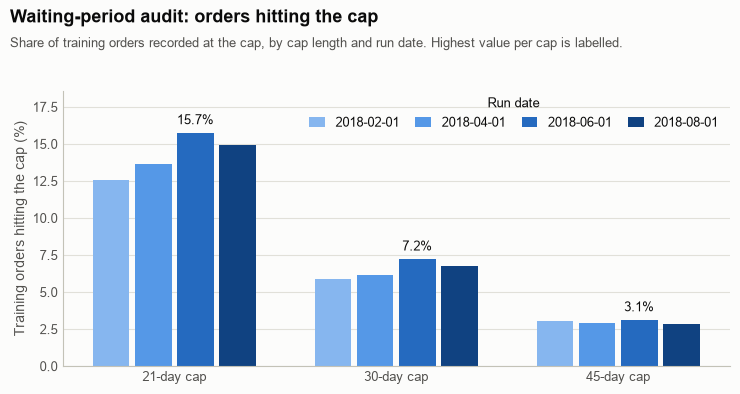

In [5]:
figs.plot_waiting_period_audit(waiting_period_audit, save_path=f'{FIGURE_DIR}/01_waiting_period_audit.png')

**Reading the audit.**
- At *W* = 45, about 1% of *delivered* orders exceed the cap. Counting shipped-but-never-delivered orders too, 2.8–3.1% of training orders are capped. Every valid target is known.
- At *W* = 30, 6–7% of training orders are capped, and at *W* = 21, 13–16%. That loses detail in exactly the long-delay tail the stakeholder cares about.
- Orders capped before their promised date, and so recorded as early, are 0.10–0.14% of training orders at *W* = 45. At *W* = 30 they are 2.2–2.4%, and at *W* = 21, 11–13%.
- **Decision: `WAITING_PERIOD = LOOKBACK = 45`.** One buffer then serves both tasks.

# Get training data

In [6]:
train_test_start_date, train_test_end_date, inference_date = get_required_dates(
    RUN_DATE, lookback=LOOKBACK, pXd=PXD)
window = final_df[final_df['order_approved_dt'].between(train_test_start_date, train_test_end_date)]
excluded = window['order_status'].isin(EXCLUDED_STATUSES)
print(f'Excluded never-delivered orders ({", ".join(EXCLUDED_STATUSES)}): {excluded.sum():,}')

reg_audit = regression_targets_as_of(window[~excluded], run_date=RUN_DATE, waiting_period=WAITING_PERIOD)
display(reg_audit['target_status'].value_counts().to_frame('orders'))
reg_df = reg_audit[reg_audit['target_as_of_run'].notna()].copy()
reg_df['y'] = reg_df['target_as_of_run'].astype(float)
print(f'Training/test orders with a known target: {len(reg_df):,}')

# The classification label for the same orders, for the dual-framing comparison later
reg_df['late_label'] = labels_as_of(reg_df, run_date=RUN_DATE)['label_as_of_run']

Train-test period for the inference date of 2018-08-01 with buffer of 45 days:
    2017-06-18 to 2018-06-17 (365 days)
Excluded never-delivered orders (canceled, unavailable): 725


,orders
target_status,
delivered_within_waiting_period,67464
capped_undelivered,1166
capped_delivered,797
invalid_or_missing_dates,12


Training/test orders with a known target: 69,427


## Training and development holdout split
- **Development holdout:** the latest `TEST_DAYS` (30) approval days of the historical window.
- **Development training:** earlier approvals, excluding the 45 days before the holdout and training outcomes not yet available when the holdout begins.

The development holdout is used to compare default and tuned candidates and select the August champion. The 45-day gap reflects the label waiting period; CV folds use the same gap and availability check. The later August orders form the evaluation cohort.

In [7]:
train_df, test_df = chronological_split(reg_df, date_col='order_approved_dt', test_days=TEST_DAYS, gap_days=WAITING_PERIOD)
train_df = available_training_rows(
    train_df, test_df['order_approved_dt'].min(), 'y',
    lambda rows, date: regression_targets_as_of(rows, date, WAITING_PERIOD), 'target_as_of_run')
train_df = train_df.sort_values('order_approved_dt', kind='stable')
X_train, y_train = train_df[REG_FEATURE_COLS], train_df['y']
X_test, y_test = test_df[REG_FEATURE_COLS], test_df['y']
print(f'Train: {train_df["order_approved_dt"].min():%Y-%m-%d} to {train_df["order_approved_dt"].max():%Y-%m-%d} '
      f'({len(train_df):,} orders, mean y {y_train.mean():.2f})')
print(f'Test:  {test_df["order_approved_dt"].min():%Y-%m-%d} to {test_df["order_approved_dt"].max():%Y-%m-%d} '
      f'({len(test_df):,} orders, mean y {y_test.mean():.2f})')


Train: 2017-06-18 to 2018-04-03 (52,930 orders, mean y -10.15)
Test:  2018-05-19 to 2018-06-17 (5,254 orders, mean y -18.70)


# Preprocessor and models
Two families across the whole project, as the brief's model-family budget requires. Each starts from its simplest variant:

| Family | Baseline | More complex |
|---|---|---|
| Linear | Linear Regression | Ridge |
| Tree-based | Decision Tree | Random Forest, LightGBM |

There are also two reference baselines. They are scored everywhere but can never be the champion:
- `DummyRegressor(median)`: the typical number of days an order arrives ahead of its promise.
- **Olist promise**: predict zero, i.e. delivery exactly on the promised date (lead time capped at the waiting period *W*). This is the bar that matters to the business: *does the model estimate delivery better than the date Olist already shows the customer?*

All preprocessing is fitted inside each pipeline, using the same `make_preprocessor` (`src/preprocessing.py`) as the classification pipelines:
- Median imputation, with scaling for the linear models only.
- One-hot encoding of categorical columns.

In [8]:
def make_pipeline(model, scale=False):
    return Pipeline([('preprocessor', make_preprocessor(REG_NUM_COLS, CAT_COLS, scale)), ('model', model)])

def clip_to_waiting_period(predicted, promised_lead_days):
    """Limit predicted days from the promise to a lead time between 0 and WAITING_PERIOD days."""
    promised = np.asarray(promised_lead_days, dtype=float)
    return np.clip(predicted, -promised, WAITING_PERIOD - promised)

class PromiseBaseline(DummyRegressor):
    """Predicts delivery on the promised date: zero days off (lead time capped at WAITING_PERIOD)."""
    def fit(self, X, y, sample_weight=None):
        return super().fit(X, y)
    def predict(self, X):
        return clip_to_waiting_period(np.zeros(len(X)), X['promised_lead_days'])

reference_models = {
    'Dummy (median)': DummyRegressor(strategy='median'),
    'Olist promise': PromiseBaseline(),
}

MODEL_FAMILY = {
    'Linear Regression': 'Linear',
    'Ridge': 'Linear',
    'Decision Tree': 'Tree-based',
    'Random Forest': 'Tree-based',
    'LightGBM': 'Tree-based',
}

# Models use n_jobs=1 so parallelism happens only across CV folds/candidates,
# which avoids oversubscribing CPU cores.
default_models = {
    'Linear Regression': make_pipeline(LinearRegression(), scale=True),
    'Ridge': make_pipeline(Ridge(), scale=True),
    'Decision Tree': make_pipeline(DecisionTreeRegressor(random_state=RANDOM_STATE)),
    'Random Forest': make_pipeline(RandomForestRegressor(n_estimators=100, max_depth=10,
                                                         random_state=RANDOM_STATE, n_jobs=1)),
    'LightGBM': make_pipeline(LGBMRegressor(random_state=RANDOM_STATE, verbosity=-1, n_jobs=1)),
}

# Small random-search spaces; widen them once the feature set is frozen.
# Linear Regression has nothing to tune.
SEARCH_SPACES = {
    'Ridge': {'model__alpha': np.logspace(-2, 3, 12)},
    'Decision Tree': {'model__max_depth': [4, 6, 8, 10, 12, None],
                      'model__min_samples_leaf': [1, 20, 50, 100, 200]},
    'Random Forest': {'model__n_estimators': [100, 200],
                      'model__max_depth': [8, 12, 16],
                      'model__min_samples_leaf': [10, 30, 60],
                      'model__max_features': [0.3, 0.5]},
    'LightGBM': {'model__n_estimators': [200, 400, 600],
                 'model__learning_rate': [0.02, 0.05, 0.1],
                 'model__num_leaves': [15, 31, 63],
                 'model__min_child_samples': [20, 50, 100],
                 'model__subsample': [0.7, 1.0], 'model__subsample_freq': [1],
                 'model__colsample_bytree': [0.6, 0.8, 1.0],
                 'model__objective': ['regression', 'regression_l1']},
}

# Time-series cross-validation & Hyperparameter tuning
Same order as the classification notebook:
1. Build the CV folds on the training part.
2. Score the default models with CV, then on the hold-out.
3. Tune with `RandomizedSearchCV` on the same folds, then score every default and tuned model on the hold-out.

## Chronological split and CV folds
- **CV:** five expanding folds, each validating on 30 calendar days.
- Leave a 45-day gap before each validation block and retain only training targets known at that block’s start.
- Keep orders from the same approval day together.

The five validation blocks are counted backwards from the end of the development-training period. For the August run, the 290-day development-training window leaves 95 initial calendar days before the first 45-day gap. As the validation date advances, each fold can use more earlier history once it is outside the 45-day gap. The date window moves with each run date; see the optional monthly comparison below.

In [9]:
# Fixed 30-calendar-day validation blocks, ordered chronologically.
# Each fold has a 45-day gap and outcome-availability check.
cv_folds = day_blocked_time_series_folds(
    train_df['order_approved_dt'], n_splits=N_CV_FOLDS,
    gap_days=WAITING_PERIOD, validation_days=CV_VALIDATION_DAYS)
cv_folds = available_outcome_folds(
    train_df, cv_folds, y_train,
    lambda rows, date: regression_targets_as_of(rows, date, WAITING_PERIOD), 'target_as_of_run')
assert len(cv_folds) == N_CV_FOLDS
print(f'CV: {len(cv_folds)} folds with a {WAITING_PERIOD}-day gap and known training targets')
display(pd.DataFrame([{
            'fold': k, 'train_orders': len(tr), 'valid_orders': len(va),
            'valid_from': train_df['order_approved_dt'].iloc[va].min().date(),
            'valid_to': train_df['order_approved_dt'].iloc[va].max().date(),
            'valid_mean_y': round(y_train.iloc[va].mean(), 2),
                  } for k, (tr, va) in enumerate(cv_folds, 1)]
            ).set_index('fold')
      )

CV: 5 folds with a 45-day gap and known training targets


,train_orders,valid_orders,valid_from,valid_to,valid_mean_y
fold,,,,,
1,12369,7750,2017-11-05,2017-12-04,-7.950
2,16706,5254,2017-12-05,2018-01-03,-13.010
3,21303,7115,2018-01-04,2018-02-02,-12.550
4,29780,7169,2018-02-03,2018-03-04,-7.650
5,35504,6918,2018-03-05,2018-04-03,-6.500


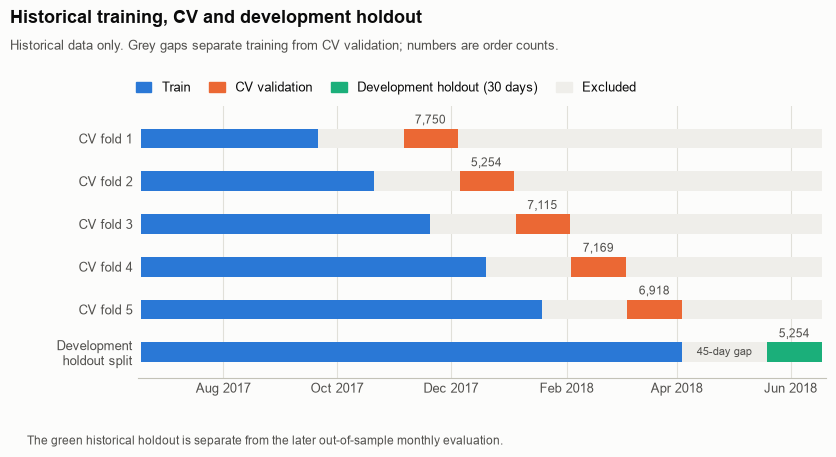

In [10]:
figs.plot_split_and_folds(train_df['order_approved_dt'], test_df['order_approved_dt'], cv_folds,
                          save_path=f'{FIGURE_DIR}/02_split_and_cv_folds.png')

## Cross-validated defaults
### Development-fold metrics
- **MAE** is the primary metric. It reads directly as "days off" in the predicted delivery date.
- RMSE and R² are reported alongside it.

In [11]:
SCORING = {'mae': 'neg_mean_absolute_error', 'rmse': 'neg_root_mean_squared_error', 'r2': 'r2'}

def cv_summary(model, X, y, folds, n_jobs=-1):
    """Mean and standard deviation of each CV score across the given folds."""
    scores = cross_validate(model, X, y, cv=folds, scoring=SCORING, n_jobs=n_jobs)
    row = {}
    for metric in SCORING:
        values = scores[f'test_{metric}'] * (1 if metric == 'r2' else -1)
        row[f'cv_{metric}_mean'], row[f'cv_{metric}_std'] = values.mean(), values.std()
    return row

cv_rows = []
for name, model in reference_models.items():
    cv_rows.append({'model': name, 'variant': 'reference', 'family': 'Reference',
                    **cv_summary(model, X_train, y_train, cv_folds)})
for name, model in default_models.items():
    cv_rows.append({'model': name, 'variant': 'default', 'family': MODEL_FAMILY[name],
                    **cv_summary(model, X_train, y_train, cv_folds)})
display(pd.DataFrame(cv_rows).set_index(['model', 'variant']))

,,family,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
model,variant,,,,,,,
Dummy (median),reference,Reference,7.310,0.760,10.530,1.064,-0.123,0.105
Olist promise,reference,Reference,12.114,1.645,13.684,1.472,-0.983,0.634
Linear Regression,default,Linear,6.453,0.448,9.662,0.762,0.053,0.069
Ridge,default,Linear,6.493,0.544,9.787,0.801,0.028,0.077
Decision Tree,default,Tree-based,9.757,0.656,13.909,0.888,-1.009,0.447
Random Forest,default,Tree-based,6.562,0.298,9.491,0.603,0.085,0.045
LightGBM,default,Tree-based,6.400,0.269,9.361,0.570,0.110,0.044


### How much does a random split flatter the scores?
This scores the same default LightGBM with random 5-fold CV on the same rows. The gap from the time-series CV is the optimism that comes from training on orders that come after some of the validation orders.

In [12]:
random_cv = cv_summary(default_models['LightGBM'], X_train, y_train,
                       KFold(5, shuffle=True, random_state=RANDOM_STATE))
time_cv = next(row for row in cv_rows if row['model'] == 'LightGBM')
display(pd.DataFrame({'random 5-fold': random_cv, 'time-series 5-fold': time_cv})
        .loc[['cv_mae_mean', 'cv_rmse_mean', 'cv_r2_mean']].astype(float))

,random 5-fold,time-series 5-fold
cv_mae_mean,5.514,6.400
cv_rmse_mean,8.011,9.361
cv_r2_mean,0.322,0.110


### Development holdout metrics
Reference baselines and default models are fitted on the development-training rows and scored once on the development holdout. The tuned models are added after the random search.

In [13]:
holdout_metrics, test_predictions, fitted_models = {}, {}, {}

def score_holdout(key, model):
    """Fit on the training part and score the hold-out; predictions are clipped to the waiting period."""
    fitted_models[key] = clone(model).fit(X_train, y_train)
    test_predictions[key] = clip_to_waiting_period(fitted_models[key].predict(X_test), X_test['promised_lead_days'])
    holdout_metrics[key] = regression_metrics(y_test, test_predictions[key])

for name, model in reference_models.items():
    score_holdout((name, 'reference'), model)
for name, model in default_models.items():
    score_holdout((name, 'default'), model)
display(pd.DataFrame(holdout_metrics).T.rename_axis(['model', 'variant']).sort_values('mae'))


,,mae,rmse,r2,median_ae,bias
model,variant,,,,,
Ridge,default,5.988,7.621,0.534,5.062,3.663
Linear Regression,default,5.994,7.626,0.534,5.075,3.681
LightGBM,default,6.354,7.974,0.490,5.611,4.166
Random Forest,default,6.987,8.571,0.411,6.516,4.824
Decision Tree,default,8.616,12.447,-0.243,6.000,4.505
Dummy (median),reference,10.769,13.422,-0.445,10.000,7.743
Olist promise,reference,18.857,21.052,-2.555,20.000,18.226


## Conduct hyperparameter tuning
1. **Hyperparameter tuning** with `RandomizedSearchCV` on the time-series folds, minimising **MAE**.
2. **Hold-out evaluation** of every default and tuned model. The champion is chosen from it in the next section.
3. **Default vs tuned, compared on:**
   - the hold-out;
   - a pooled monthly backtest (April–July 2018) on a moving window.

### Random search
Each model searches a small grid (`SEARCH_SPACES` above) on the time-series folds, minimising mean MAE.
- Linear Regression has no hyperparameters, so it has a default variant only.
- The hold-out is not used for tuning.

In [14]:
tuned_models, best_params = {}, {}
for name, space in SEARCH_SPACES.items():
    search = RandomizedSearchCV(default_models[name], space, n_iter=N_ITER[name], cv=cv_folds,
                                scoring='neg_mean_absolute_error', random_state=RANDOM_STATE,
                                n_jobs=-1, refit=False)
    search.fit(X_train, y_train)
    best_params[name] = {key: (value.item() if isinstance(value, np.generic) else value)
                         for key, value in search.best_params_.items()}
    tuned_models[name] = clone(default_models[name]).set_params(**search.best_params_)
    cv_rows.append({'model': name, 'variant': 'tuned', 'family': MODEL_FAMILY[name],
                    **cv_summary(tuned_models[name], X_train, y_train, cv_folds)})
    print(f'{name}: {best_params[name]}')

cv_results = pd.DataFrame(cv_rows).set_index(['model', 'variant']).sort_index()
display(cv_results)
display((cv_results.xs('default', level='variant')['cv_mae_mean']
         - cv_results.xs('tuned', level='variant')['cv_mae_mean'])
        .dropna().rename('cv_mae_reduction_from_tuning').to_frame())

Ridge: {'model__alpha': 0.01}


Decision Tree: {'model__min_samples_leaf': 100, 'model__max_depth': None}


Random Forest: {'model__n_estimators': 200, 'model__min_samples_leaf': 60, 'model__max_features': 0.5, 'model__max_depth': 16}


LightGBM: {'model__subsample_freq': 1, 'model__subsample': 1.0, 'model__objective': 'regression', 'model__num_leaves': 31, 'model__n_estimators': 400, 'model__min_child_samples': 50, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8}


family  cv_mae_mean  cv_mae_std  \
model             variant                                          
Decision Tree     default    Tree-based        9.757       0.656   
                  tuned      Tree-based        6.551       0.386   
Dummy (median)    reference   Reference        7.310       0.760   
LightGBM          default    Tree-based        6.400       0.269   
                  tuned      Tree-based        6.417       0.253   
Linear Regression default        Linear        6.453       0.448   
Olist promise     reference   Reference       12.114       1.645   
Random Forest     default    Tree-based        6.562       0.298   
                  tuned      Tree-based        6.435       0.404   
Ridge             default        Linear        6.493       0.544   
                  tuned          Linear        6.454       0.451   

                             cv_rmse_mean  cv_rmse_std  cv_r2_mean  cv_r2_std  
model             variant                                                      
Decision Tree     default          13.909        0.888      -1.009      0.447  
                  tuned             9.681        0.544       0.047      0.051  
Dummy (median)    reference        10.530        1.064      -0.123      0.105  
LightGBM          default           9.361        0.570       0.110      0.044  
                  tuned             9.373        0.573       0.107      0.047  
Linear Regression default           9.662        0.762       0.053      0.069  
Olist promise     reference        13.684        1.472      -0.983      0.634  
Random Forest     default           9.491        0.603       0.085      0.045  
                  tuned             9.550        0.713       0.075      0.048  
Ridge             default           9.787        0.801       0.028      0.077  
                  tuned             9.666        0.764       0.052      0.069

,cv_mae_reduction_from_tuning
model,
Decision Tree,3.207
LightGBM,-0.018
Random Forest,0.128
Ridge,0.039


In [15]:
candidate_models = {**{(name, 'default'): model for name, model in default_models.items()},
                    **{(name, 'tuned'): model for name, model in tuned_models.items()}}

leaderboard = cv_results.loc[list(candidate_models),
                             ['family', 'cv_mae_mean', 'cv_mae_std', 'cv_rmse_mean', 'cv_r2_mean']]
leaderboard = leaderboard.sort_values('cv_mae_mean')
leaderboard['mae_gap_to_best'] = leaderboard['cv_mae_mean'] - leaderboard['cv_mae_mean'].iloc[0]
display(leaderboard)


family  cv_mae_mean  cv_mae_std  cv_rmse_mean  \
model             variant                                                      
LightGBM          default  Tree-based        6.400       0.269         9.361   
                  tuned    Tree-based        6.417       0.253         9.373   
Random Forest     tuned    Tree-based        6.435       0.404         9.550   
Linear Regression default      Linear        6.453       0.448         9.662   
Ridge             tuned        Linear        6.454       0.451         9.666   
                  default      Linear        6.493       0.544         9.787   
Decision Tree     tuned    Tree-based        6.551       0.386         9.681   
Random Forest     default  Tree-based        6.562       0.298         9.491   
Decision Tree     default  Tree-based        9.757       0.656        13.909   

                           cv_r2_mean  mae_gap_to_best  
model             variant                               
LightGBM          default       0.110            0.000  
                  tuned         0.107            0.018  
Random Forest     tuned         0.075            0.035  
Linear Regression default       0.053            0.054  
Ridge             tuned         0.052            0.055  
                  default       0.028            0.094  
Decision Tree     tuned         0.047            0.151  
Random Forest     default       0.085            0.163  
Decision Tree     default      -1.009            3.358

### Development holdout evaluation (newest 30 days of the window)

In [16]:
scored_models = {**{(name, 'reference'): model for name, model in reference_models.items()},
                 **candidate_models}
for name, model in tuned_models.items():
    score_holdout((name, 'tuned'), model)
holdout_results = pd.DataFrame(holdout_metrics).T.rename_axis(['model', 'variant']).sort_values('mae')
display(holdout_results)


mae   rmse     r2  median_ae   bias
model             variant                                         
Ridge             default    5.988  7.621  0.534      5.062  3.663
                  tuned      5.993  7.626  0.534      5.074  3.681
Linear Regression default    5.994  7.626  0.534      5.075  3.681
LightGBM          tuned      6.184  7.836  0.507      5.317  3.931
                  default    6.354  7.974  0.490      5.611  4.166
Random Forest     tuned      6.681  8.290  0.449      6.056  4.523
Decision Tree     tuned      6.816  8.551  0.414      6.050  4.444
Random Forest     default    6.987  8.571  0.411      6.516  4.824
Decision Tree     default    8.616 12.447 -0.243      6.000  4.505
Dummy (median)    reference 10.769 13.422 -0.445     10.000  7.743
Olist promise     reference 18.857 21.052 -2.555     20.000 18.226

# Use best-performing model for prediction
This section selects the champion using the development holdout. The August report then refits all candidates on eligible historical outcomes and evaluates their predictions on August orders.

## Champion: lowest hold-out MAE
The **champion** is the candidate with the lowest development-holdout MAE among every default and tuned model. The two reference baselines are not candidates. This is the same rule as the classification notebook, which picks its model from hold-out metrics.

- At training time the hold-out is the newest labelled data, so it is the closest available stand-in for the orders the model will score next.
- Because the hold-out is used for this choice, the champion's holdout MAE is not an unbiased estimate. The August inference cohort provides the later evaluation sample.
- The August champion is selected from the August development holdout.

In [17]:
def select_champion(holdout_mae):
    """Return the (model, variant) with the lowest hold-out MAE; `holdout_mae` maps each candidate to its MAE."""
    return min(holdout_mae, key=holdout_mae.get)

champion_key = select_champion({key: holdout_results.loc[key, 'mae'] for key in candidate_models})
champion_name, champion_variant = champion_key
champion_label = f'{champion_name} ({champion_variant})'
champion_model = fitted_models[champion_key]
holdout_results.insert(0, 'champion', [key == champion_key for key in holdout_results.index])
display(holdout_results)

print(f'Champion: {champion_label}, hold-out MAE {holdout_results.loc[champion_key, "mae"]:.3f} days '
      f'(CV MAE {cv_results.loc[champion_key, "cv_mae_mean"]:.3f})')
for reference in reference_models:
    gain = holdout_results.loc[(reference, 'reference'), 'mae'] - holdout_results.loc[champion_key, 'mae']
    print(f'  Hold-out MAE improvement over {reference}: {gain:.2f} days')


champion    mae   rmse     r2  median_ae   bias
model             variant                                                   
Ridge             default        True  5.988  7.621  0.534      5.062  3.663
                  tuned         False  5.993  7.626  0.534      5.074  3.681
Linear Regression default       False  5.994  7.626  0.534      5.075  3.681
LightGBM          tuned         False  6.184  7.836  0.507      5.317  3.931
                  default       False  6.354  7.974  0.490      5.611  4.166
Random Forest     tuned         False  6.681  8.290  0.449      6.056  4.523
Decision Tree     tuned         False  6.816  8.551  0.414      6.050  4.444
Random Forest     default       False  6.987  8.571  0.411      6.516  4.824
Decision Tree     default       False  8.616 12.447 -0.243      6.000  4.505
Dummy (median)    reference     False 10.769 13.422 -0.445     10.000  7.743
Olist promise     reference     False 18.857 21.052 -2.555     20.000 18.226

Champion: Ridge (default), hold-out MAE 5.988 days (CV MAE 6.493)
  Hold-out MAE improvement over Dummy (median): 4.78 days
  Hold-out MAE improvement over Olist promise: 12.87 days


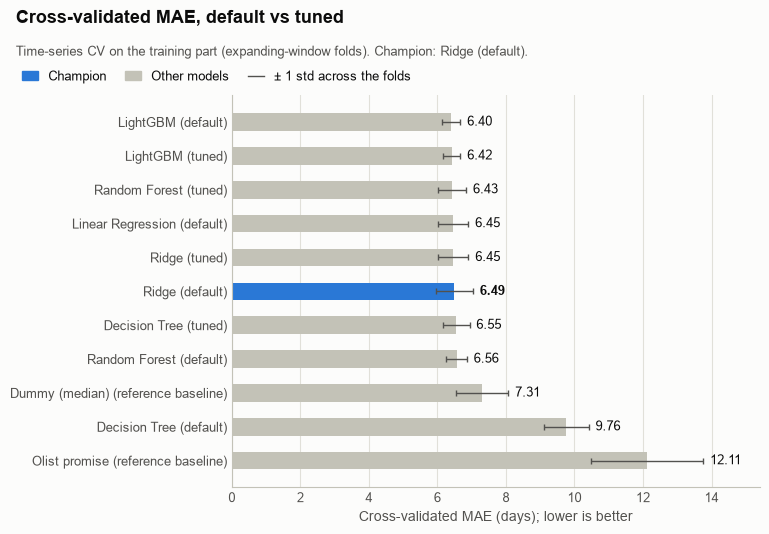

In [18]:
figs.plot_cv_mae(cv_results, champion_key, save_path=f'{FIGURE_DIR}/03_cv_mae_default_vs_tuned.png')

## Interpretation
The champion is fitted on the development-training rows and explained on the development holdout.

### Permutation importance (development holdout, raw features)

In [19]:
perm = permutation_importance(champion_model, X_test, y_test, n_repeats=5, random_state=RANDOM_STATE,
                              scoring='neg_mean_absolute_error', n_jobs=-1)
importance = (pd.DataFrame({'feature': REG_FEATURE_COLS,
                            'mae_increase_days': perm.importances_mean,
                            'std': perm.importances_std})
              .sort_values('mae_increase_days', ascending=False).head(20).reset_index(drop=True))
display(importance)

,feature,mae_increase_days,std
0,promised_lead_days,6.653,0.098
1,seller_dist_km_median,2.518,0.050
2,seller_dist_km_min,1.497,0.026
3,payment_value_sum,0.525,0.015
4,order_pdt_price_sum,0.391,0.005
5,payment_type_value_credit_card,0.380,0.014
6,order_revenue_sum,0.369,0.004
7,order_approved_week_of_year,0.199,0.008
8,seller_dist_km_max,0.133,0.011
9,orders_approved_prev_7d,0.122,0.006


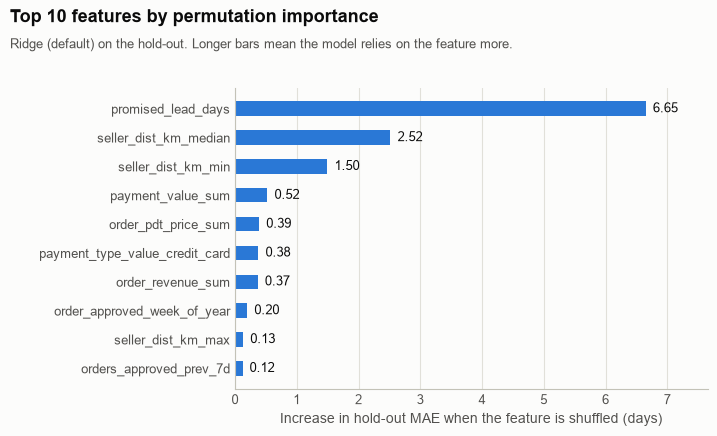

In [20]:
figs.plot_feature_importance(importance.head(10), champion_label,
                             save_path=f'{FIGURE_DIR}/06_feature_importance.png')

### Residuals by segment

,orders,actual_mean,predicted_mean,bias,mae
route_type,,,,,
1. All interstate,3067,-21.774,-16.913,4.862,7.060
2. All same-state,2166,-14.295,-12.306,1.989,4.493
3. Mixed,21,-23.524,-22.253,1.270,3.560


,orders,actual_mean,predicted_mean,bias,mae
customer_state,,,,,
SP,2516,-15.526,-13.253,2.272,4.676
RJ,621,-25.926,-17.952,7.974,9.693
MG,571,-20.030,-16.496,3.533,5.714
PR,240,-20.083,-17.083,3.001,4.979
RS,230,-24.435,-18.839,5.596,6.452
BA,189,-17.095,-15.132,1.963,7.779
SC,167,-19.844,-14.524,5.320,6.261
DF,113,-18.929,-13.924,5.006,6.049
ES,91,-14.890,-13.711,1.179,6.575


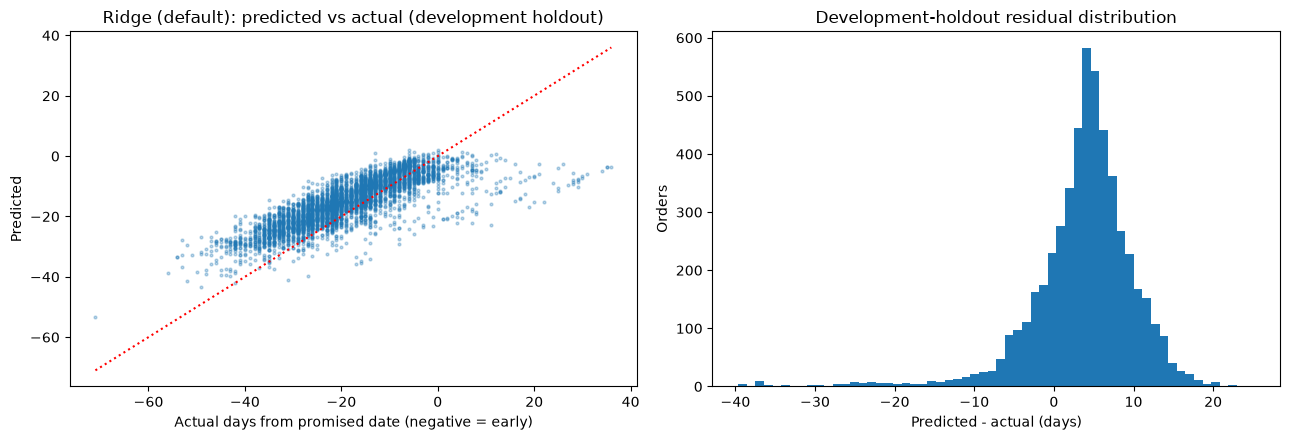

In [21]:
residuals = test_df[['customer_state', 'route_type']].copy()
residuals['actual'] = y_test.to_numpy()
residuals['predicted'] = test_predictions[champion_key]
residuals['error'] = residuals['predicted'] - residuals['actual']
for segment in ['route_type', 'customer_state']:
    table = residuals.groupby(segment).agg(orders=('error', 'size'), actual_mean=('actual', 'mean'),
                                           predicted_mean=('predicted', 'mean'), bias=('error', 'mean'),
                                           mae=('error', lambda e: e.abs().mean()))
    display(table.sort_values('orders', ascending=False).head(12))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(residuals['actual'], residuals['predicted'], s=4, alpha=0.3)
limits = [residuals[['actual', 'predicted']].min().min(), residuals[['actual', 'predicted']].max().max()]
axes[0].plot(limits, limits, color='red', linestyle=':')
axes[0].set(xlabel='Actual days from promised date (negative = early)', ylabel='Predicted',
            title=f'{champion_label}: predicted vs actual (development holdout)')
axes[1].hist(residuals['error'], bins=60)
axes[1].set(xlabel='Predicted - actual (days)', ylabel='Orders', title='Development-holdout residual distribution')
plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}/08_predicted_vs_actual.png', dpi=200)
plt.show()

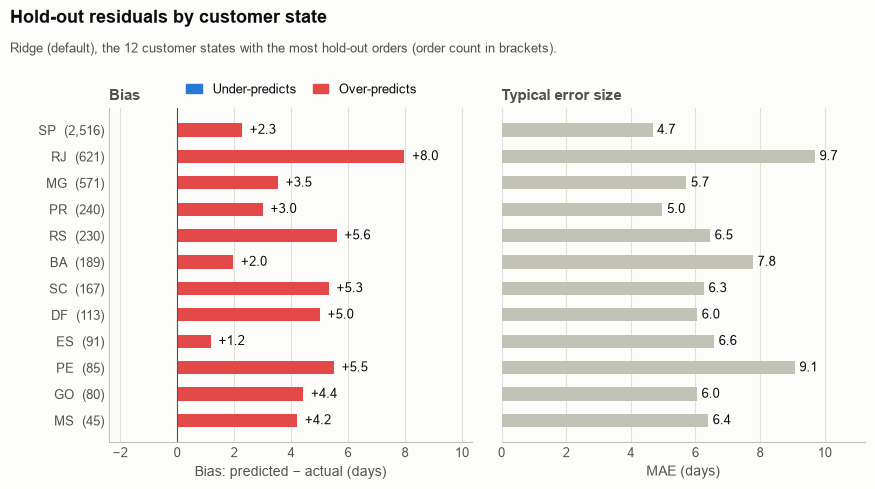

In [22]:
figs.plot_residuals_by_state(residuals, champion_label,
                             save_path=f'{FIGURE_DIR}/07_residuals_by_state.png')

## Dual framing: a late flag derived from the regression output
An order is flagged late when the champion's **predicted days from the promised date are above zero**. This is the same outcome as the classification label.

The table compares this flag on the same August development holdout with:
- a LightGBM classifier trained on the same features and split, at a 0.5 threshold;
- a Logistic Regression classifier.

It also checks what the new features add to the classifier. PR-AUC is compared with the base feature set (`NUM_COLS + CAT_COLS`) and with the extended one.

In [23]:
# A few orders have a regression target but no late label yet (promised date still ahead)
test_known, train_known = test_df['late_label'].notna(), train_df['late_label'].notna()
print(f'Orders without a known late label (excluded here): training {(~train_known).sum()}, development holdout {(~test_known).sum()}')
cls_train, cls_test = train_df[train_known], test_df[test_known]
test_late = cls_test['late_label'].astype(int)
train_late = cls_train['late_label'].astype(int)
margin = test_predictions[champion_key][test_known.to_numpy()]  # Predicted days after the promise
dual_rows = {'Regression-derived flag': classification_metrics(test_late, (margin > 0).astype(int), margin)}

def fit_classifier(model, num_cols, scale):
    pipeline = Pipeline([('preprocessor', make_preprocessor(num_cols, CAT_COLS, scale)), ('model', model)])
    pipeline.fit(cls_train[num_cols + CAT_COLS], train_late)
    prob = pipeline.predict_proba(cls_test[num_cols + CAT_COLS])[:, 1]
    return classification_metrics(test_late, (prob >= 0.5).astype(int), prob)

ratio = (train_late == 0).sum() / (train_late == 1).sum()
for label, cols in [('v2 features', NUM_COLS), ('v2 + extra features', REG_NUM_COLS)]:
    dual_rows[f'LightGBM classifier ({label})'] = fit_classifier(
        LGBMClassifier(scale_pos_weight=ratio, random_state=RANDOM_STATE, verbosity=-1), cols, scale=False)
    dual_rows[f'LogisticRegression ({label})'] = fit_classifier(
        LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE), cols, scale=True)
print(f'Development-holdout late rate: {test_late.mean():.2%}')
display(pd.DataFrame(dual_rows).T)

Orders without a known late label (excluded here): training 0, development holdout 0


Development-holdout late rate: 3.31%


,roc_auc,avg_precision,accuracy,precision,recall,f1_score
Regression-derived flag,0.785,0.146,0.965,0.300,0.034,0.062
LightGBM classifier (v2 features),0.667,0.054,0.854,0.060,0.230,0.095
LogisticRegression (v2 features),0.574,0.042,0.681,0.045,0.425,0.081
LightGBM classifier (v2 + extra features),0.743,0.114,0.805,0.091,0.546,0.157
LogisticRegression (v2 + extra features),0.787,0.129,0.843,0.106,0.506,0.176


## Optional historical sensitivity backtest with June-tuned settings, April–July 2018

This earlier analysis is preserved as a fixed-parameter comparison. For each run date, its own buffered holdout selects among the June default and tuned candidates; the hyperparameters themselves come from the June CV search and are reused for April–July. April and May are therefore retrospective comparisons, not simulations of tuning available at those dates. This optional analysis is disabled by default; enable `RUN_SENSITIVITY_BACKTEST` to run it.

For each run date, the notebook builds that date's eligible 365-day history, checks that holdout training outcomes were known at the holdout start, refits candidates on the full eligible history and scores that month's orders. Evaluation labels use the 45-day waiting period. The delivery table's latest timestamp is an observation-end proxy, so orders without full follow-up are excluded from reports.

In [24]:
def backtest_month(run_date):
    start, end, _ = get_required_dates(run_date, lookback=LOOKBACK, pXd=PXD, verbose=False)
    history = final_df[final_df['order_approved_dt'].between(start, end)
                       & ~final_df['order_status'].isin(EXCLUDED_STATUSES)]
    targets = regression_targets_as_of(history, run_date=run_date, waiting_period=WAITING_PERIOD)
    targets = targets[targets['target_as_of_run'].notna()]
    targets = targets.assign(y=targets['target_as_of_run'].astype(float))

    # Champion as of this run date: lowest MAE on this window's own hold-out
    month_train, month_holdout = chronological_split(targets, date_col='order_approved_dt', test_days=TEST_DAYS, gap_days=WAITING_PERIOD)
    month_train = available_training_rows(
        month_train, month_holdout['order_approved_dt'].min(), 'y',
        lambda rows, date: regression_targets_as_of(rows, date, WAITING_PERIOD), 'target_as_of_run')
    month_holdout_mae = {}
    for key, model in candidate_models.items():
        fitted = clone(model).fit(month_train[REG_FEATURE_COLS], month_train['y'])
        predicted = clip_to_waiting_period(fitted.predict(month_holdout[REG_FEATURE_COLS]),
                                    month_holdout['promised_lead_days'])
        month_holdout_mae[key] = regression_metrics(month_holdout['y'], predicted)['mae']
    month_champion = select_champion(month_holdout_mae)

    month = pd.Period(run_date, 'M')
    cohort = final_df[final_df['order_approved_dt'].dt.to_period('M').eq(month)]
    frames = []
    for (name, variant), model in scored_models.items():
        fitted = clone(model).fit(targets[REG_FEATURE_COLS], targets['y'])
        frame = cohort[['order_id', 'order_approved_dt']].copy()
        frame['predicted'] = clip_to_waiting_period(fitted.predict(cohort[REG_FEATURE_COLS]), cohort['promised_lead_days'])
        frame['model'], frame['variant'], frame['month'] = name, variant, str(month)
        frames.append(frame)
        if (name, variant) == month_champion:
            frames.append(frame.assign(model='Champion', variant='re-selected monthly'))
    champion_row = {'month': str(month), 'train_orders': len(targets),
                    'champion': f'{month_champion[0]} ({month_champion[1]})',
                    'champion_holdout_mae': month_holdout_mae[month_champion]}
    return pd.concat(frames, ignore_index=True), champion_row

if RUN_SENSITIVITY_BACKTEST:
    backtest_runs = Parallel(n_jobs=-1)(delayed(backtest_month)(d) for d in BACKTEST_RUN_DATES)
    backtest = pd.concat([predictions for predictions, _ in backtest_runs], ignore_index=True)
    backtest_actuals = attach_regression_actuals(backtest[['order_id']].drop_duplicates(), orders,
                                                 waiting_period=WAITING_PERIOD)
    backtest = backtest.merge(backtest_actuals[['order_id', 'actual_target', 'target_status']], on='order_id')
    known_orders = backtest_actuals['actual_target'].notna()
    print(f'April-July backtest orders: known targets at approval day + {WAITING_PERIOD} days: '
          f'{known_orders.sum():,}/{len(backtest_actuals):,} ({known_orders.mean():.2%})')
else:
    champions = pd.DataFrame(columns=['champion'])
    print('Optional April–July sensitivity backtest skipped.')

Optional April–July sensitivity backtest skipped.


In [25]:
if RUN_SENSITIVITY_BACKTEST:
    def backtest_metrics(group):
        known = group[group['actual_target'].notna()]
        return pd.Series(regression_metrics(known['actual_target'].astype(float), known['predicted']))

    backtest_monthly = backtest.groupby(['month', 'model', 'variant']).apply(backtest_metrics).reset_index()

    # Which candidate actually scored best each month, to check the champion picks
    candidates_monthly = backtest_monthly[backtest_monthly['variant'].isin(['default', 'tuned'])]
    hindsight = candidates_monthly.loc[candidates_monthly.groupby('month')['mae'].idxmin()].set_index('month')
    champions = pd.DataFrame([row for _, row in backtest_runs]).set_index('month')
    champions['champion_backtest_mae'] = (backtest_monthly[backtest_monthly['model'].eq('Champion')]
                                          .set_index('month')['mae'])
    champions['best_in_hindsight'] = hindsight['model'] + ' (' + hindsight['variant'] + ')'
    champions['best_in_hindsight_mae'] = hindsight['mae']
    print('Champion at each run date:')
    display(champions)

    print('MAE by month:')
    display(backtest_monthly.pivot_table(index=['model', 'variant'], columns='month', values='mae'))
    print('Equal-weight monthly mean and std:')
    display(backtest_monthly.groupby(['model', 'variant'])[['mae', 'rmse', 'r2', 'bias']]
            .agg(['mean', 'std']).sort_values(('mae', 'mean')))
    print('Pooled over all four months:')
    backtest_pooled = backtest.groupby(['model', 'variant']).apply(backtest_metrics).sort_values('mae')
    display(backtest_pooled)

In [26]:
if RUN_SENSITIVITY_BACKTEST:
    figs.plot_backtest_by_month(backtest_monthly, [
        ('Champion', 're-selected monthly', 'Champion (re-selected monthly)'),
        ('Linear Regression', 'default', 'Linear Regression'),
        ('Dummy (median)', 'reference', 'Dummy median'),
        ('Olist promise', 'reference', "Olist's promised date"),
    ], save_path=f'{FIGURE_DIR}/05_monthly_backtest_mae.png')
    figs.plot_mae_across_evaluations(cv_results, holdout_results, backtest_pooled, champion_key,
                                     save_path=f'{FIGURE_DIR}/04_mae_cv_holdout_backtest.png')

## Optional resampling experiment: over- and undersampling late orders
A regression target has no classes, so resampling is done on the side of the target that matters to the business: **late orders** (y > 0) against early and on-time orders (y ≤ 0).
- **Oversampling** repeats late training orders at random until the two groups are the same size.
- **Undersampling** drops early and on-time training orders at random until the two groups are the same size.
- Only training rows are resampled. The hold-out and the backtest months are scored as they are.

The champion's pipeline is refitted on each version of the training data and compared on:
- the hold-out (fitted on the training part);
- the April–July backtest (fitted on each run date's whole window, as in the backtest above).

MAE is shown overall and separately for late and other orders. The late flag is "predicted days above zero".

In [27]:
if RUN_RESAMPLING:
    def resample_training(rows, method, random_state=RANDOM_STATE):
        """Balance late orders (y > 0) against the rest 1:1; `method` is 'none', 'oversample' or 'undersample'."""
        late, rest = rows[rows['y'] > 0], rows[rows['y'] <= 0]
        if method == 'oversample':
            late = late.sample(len(rest), replace=True, random_state=random_state)
        elif method == 'undersample':
            rest = rest.sample(len(late), replace=False, random_state=random_state)
        elif method != 'none':
            raise ValueError(f'Unknown resampling method: {method}')
        return pd.concat([late, rest]).sort_values('order_approved_dt', kind='stable')

    def resampling_metrics(actual, predicted):
        """Regression errors overall and by actual lateness, plus the derived late flag."""
        actual, predicted = np.asarray(actual, dtype=float), np.asarray(predicted, dtype=float)
        late, error = actual > 0, np.abs(predicted - actual)
        flag = classification_metrics(late.astype(int), (predicted > 0).astype(int), predicted)
        return {'mae': error.mean(), 'mae_late_orders': error[late].mean(), 'mae_other_orders': error[~late].mean(),
                'bias': (predicted - actual).mean(), 'flagged_pct': 100 * (predicted > 0).mean(),
                'flag_precision': flag['precision'], 'flag_recall': flag['recall'], 'flag_pr_auc': flag['pr_auc']}

    def fit_resampled(rows, method):
        sample = resample_training(rows, method)
        fitted = clone(candidate_models[champion_key]).fit(sample[REG_FEATURE_COLS], sample['y'])
        return fitted, {'train_rows': len(sample), 'train_late_pct': 100 * (sample['y'] > 0).mean()}

    RESAMPLING_METHODS = ['none', 'oversample', 'undersample']

    # Hold-out: fit on the training part
    resampling_holdout = {}
    for method in RESAMPLING_METHODS:
        fitted, sizes = fit_resampled(train_df, method)
        predicted = clip_to_waiting_period(fitted.predict(X_test), X_test['promised_lead_days'])
        resampling_holdout[method] = {**sizes, **resampling_metrics(y_test, predicted)}
    resampling_holdout = pd.DataFrame(resampling_holdout).T.rename_axis('resampling')
    print(f'{champion_label} on the hold-out (late orders: {100 * (y_test > 0).mean():.1f}% of the hold-out)')
    display(resampling_holdout)

    # Backtest: fit on each run date's whole window and score that month's orders
    def resampling_backtest_month(run_date, method):
        start, end, _ = get_required_dates(run_date, lookback=LOOKBACK, pXd=PXD, verbose=False)
        history = final_df[final_df['order_approved_dt'].between(start, end)
                           & ~final_df['order_status'].isin(EXCLUDED_STATUSES)]
        targets = regression_targets_as_of(history, run_date=run_date, waiting_period=WAITING_PERIOD)
        targets = targets[targets['target_as_of_run'].notna()]
        targets = targets.assign(y=targets['target_as_of_run'].astype(float))
        fitted, _ = fit_resampled(targets, method)
        cohort = final_df[final_df['order_approved_dt'].dt.to_period('M').eq(pd.Period(run_date, 'M'))]
        frame = cohort[['order_id']].copy()
        frame['predicted'] = clip_to_waiting_period(fitted.predict(cohort[REG_FEATURE_COLS]), cohort['promised_lead_days'])
        return frame.assign(resampling=method)

    resampling_backtest = pd.concat(Parallel(n_jobs=-1)(
        delayed(resampling_backtest_month)(run_date, method)
        for run_date in BACKTEST_RUN_DATES for method in RESAMPLING_METHODS), ignore_index=True)
    resampling_backtest = resampling_backtest.merge(backtest_actuals[['order_id', 'actual_target']], on='order_id')
    resampling_backtest = resampling_backtest[resampling_backtest['actual_target'].notna()]
    resampling_backtest_pooled = pd.DataFrame({
        method: resampling_metrics(group['actual_target'].astype(float), group['predicted'])
        for method, group in resampling_backtest.groupby('resampling')}).T.loc[RESAMPLING_METHODS].rename_axis('resampling')
    print(f'{champion_label}, April-July backtest pooled')
    display(resampling_backtest_pooled)

else:
    print('Optional resampling experiment skipped.')

Optional resampling experiment skipped.


## Save tuned parameters and the champion

In [28]:
os.makedirs('results', exist_ok=True)
regression_output = {
    'target': 'days from estimated delivery date (negative = early), lead time capped at waiting_period_days',
    'run_date': RUN_DATE, 'waiting_period_days': WAITING_PERIOD, 'test_days': TEST_DAYS,
    'cv': f'{N_CV_FOLDS}-fold day-blocked expanding window',
    'cv_gap_days': WAITING_PERIOD, 'cv_validation_days': CV_VALIDATION_DAYS,
    'cv_initial_train_days': int((train_df['order_approved_dt'].iloc[cv_folds[0][1]].min().normalize()
                                  - pd.Timedelta(days=WAITING_PERIOD)
                                  - train_df['order_approved_dt'].min().normalize()).days),
    'scoring': 'neg_mean_absolute_error',
    'champion_selection': 'lowest hold-out MAE',
    'champion': {'model': champion_name, 'variant': champion_variant,
                 'holdout_mae': holdout_results.loc[champion_key, 'mae'],
                 'cv_mae': cv_results.loc[champion_key, 'cv_mae_mean']},
    'backtest_champions': champions['champion'].to_dict(),
    'models': {name: {'family': MODEL_FAMILY[name], 'best_params': best_params.get(name, {}),
                      'cv_mae_default': cv_results.loc[(name, 'default'), 'cv_mae_mean'],
                      'cv_mae_tuned': (cv_results.loc[(name, 'tuned'), 'cv_mae_mean']
                                       if name in tuned_models else None)}
               for name in default_models},
}
with open('results/regression_tuning.json', 'w') as f:
    json.dump(regression_output, f, indent=2)
print('Saved results/regression_tuning.json')

Saved results/regression_tuning.json


## August development and optional fixed-parameter sensitivity results

The main August development run tunes candidate settings with five expanding chronological folds, 30-day validation windows, 45-day gaps and target-availability checks. Its separate 30-day historical holdout, also preceded by a 45-day gap, selects among default and tuned candidates. The notebook outputs show the current CV and holdout results.

The preserved April–July sensitivity analysis reuses settings tuned on the June window. It is optional and is not used for the August primary results. The August report tables summarize CV, development-holdout and inference-cohort performance.

Resampling results remain exploratory: balancing late against early/on-time orders may improve one subgroup's error while worsening overall MAE.

## Optional comparison: fresh monthly tuning, June–August

When `RUN_MONTHLY_COMPARISON=True`, this section rebuilds the eligible 365-day history, applies the 45-day buffered development holdout and five 30-day CV validation blocks, and checks target availability at each split. Random search is rerun on that month's CV folds. Default and tuned candidates are compared on the same holdout, the selected candidate is refitted on all eligible outcomes known by that run date, and the model scores that month's orders. June–August order outcomes are used only for evaluation after their 45-day waiting period.

This optional comparison is separate from the August primary report. The monthly results use fresh searches and each month’s eligible inference orders.

August champion: Ridge (default)
August cohort: 6,620 scored; 6,612 evaluated
{'html': PosixPath('results/report_tables/regression_report.html'), 'latex': PosixPath('results/report_tables/regression_report.tex')}


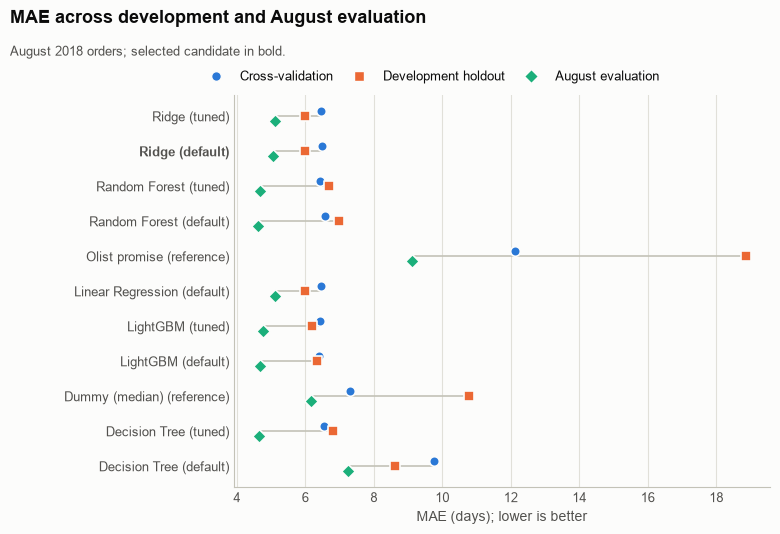

In [29]:
if RUN_MONTHLY_COMPARISON:
    from pathlib import Path
    import json
    from src.report_tables import export_report_tables

    REPORT_RUN_DATES = ['2018-06-02', '2018-07-02', '2018-08-02']
    REPORT_MONTHS = [str(pd.Period(run_date, 'M')) for run_date in REPORT_RUN_DATES]
    REPORT_DIR = Path('results/report_tables/monthly_comparison')
    REPORT_DIR.mkdir(parents=True, exist_ok=True)


    def tune_and_score_month(run_date):
        """Tune on this run's buffered CV folds, select on hold-out, then refit for its month."""
        start, end, _ = get_required_dates(run_date, lookback=LOOKBACK, pXd=PXD, verbose=False)
        history = final_df.loc[
            final_df['order_approved_dt'].between(start, end)
            & ~final_df['order_status'].isin(EXCLUDED_STATUSES)
        ]
        targets = regression_targets_as_of(history, run_date=run_date, waiting_period=WAITING_PERIOD)
        targets = targets.loc[targets['target_as_of_run'].notna()].copy()
        targets['y'] = targets['target_as_of_run'].astype(float)

        development_train, holdout = chronological_split(
            targets, date_col='order_approved_dt', test_days=TEST_DAYS, gap_days=WAITING_PERIOD
        )
        development_train = available_training_rows(
            development_train, holdout['order_approved_dt'].min(), 'y',
            lambda rows, date: regression_targets_as_of(rows, date, WAITING_PERIOD), 'target_as_of_run'
        ).sort_values('order_approved_dt', kind='stable')
        X_train, y_train = development_train[REG_FEATURE_COLS], development_train['y']
        X_holdout, y_holdout = holdout[REG_FEATURE_COLS], holdout['y']

        folds = day_blocked_time_series_folds(
            development_train['order_approved_dt'], n_splits=N_CV_FOLDS,
            gap_days=WAITING_PERIOD, validation_days=CV_VALIDATION_DAYS
        )
        folds = available_outcome_folds(
            development_train, folds, y_train,
            lambda rows, date: regression_targets_as_of(rows, date, WAITING_PERIOD), 'target_as_of_run'
        )
        assert len(folds) == N_CV_FOLDS

        month = str(pd.Period(run_date, 'M'))
        month_cv_rows, month_param_rows = [], []
        tuned_month_models, month_params = {}, {}
        for name, default_model in default_models.items():
            default_scores = cross_validate(
                default_model, X_train, y_train, cv=folds,
                scoring='neg_mean_absolute_error', n_jobs=-1
            )['test_score']
            default_mae = float(-default_scores.mean())
            month_cv_rows.append({'Period': month, 'Model': name, 'Variant': 'default',
                                  'CV_MAE_days': default_mae, 'CV_MAE_std_days': float(default_scores.std())})

            if name in SEARCH_SPACES:
                search = RandomizedSearchCV(
                    default_model, SEARCH_SPACES[name], n_iter=N_ITER[name], cv=folds,
                    scoring='neg_mean_absolute_error', random_state=RANDOM_STATE,
                    n_jobs=-1, refit=False,
                )
                search.fit(X_train, y_train)
                params = {key: (value.item() if isinstance(value, np.generic) else value)
                          for key, value in search.best_params_.items()}
                tuned_month_models[name] = clone(default_model).set_params(**search.best_params_)
                month_params[name] = params
                month_cv_rows.append({'Period': month, 'Model': name, 'Variant': 'tuned',
                                      'CV_MAE_days': float(-search.best_score_),
                                      'CV_MAE_std_days': float(search.cv_results_['std_test_score'][search.best_index_])})
                month_param_rows.append({'Period': month, 'Model': name,
                                         'Best_CV_MAE_days': float(-search.best_score_),
                                         'Parameters': json.dumps(params, sort_keys=True)})

        candidates = {
            **{(name, 'default'): model for name, model in default_models.items()},
            **{(name, 'tuned'): model for name, model in tuned_month_models.items()},
        }
        holdout_models = {**reference_models, **candidates}
        holdout_scores, holdout_rows = {}, []
        for key, model in holdout_models.items():
            fitted = clone(model).fit(X_train, y_train)
            prediction = clip_to_waiting_period(fitted.predict(X_holdout), X_holdout['promised_lead_days'])
            metrics = regression_metrics(y_holdout, prediction)
            holdout_scores[key] = metrics['mae']
            model_name, variant = key if isinstance(key, tuple) else (key, 'reference')
            holdout_rows.append({'Period': month, 'Model': model_name, 'Variant': variant,
                                 'Orders': len(holdout), 'Holdout_MAE_days': metrics['mae']})

        champion_key = min(candidates, key=holdout_scores.get)
        champion_model_name, champion_variant = champion_key
        cohort = final_df.loc[
            final_df['order_approved_dt'].dt.to_period('M').eq(pd.Period(run_date, 'M'))
        ]
        prediction_frames, fitted_predictions = [], {}
        full_models = {**reference_models, **candidates}
        for key, model in full_models.items():
            fitted = clone(model).fit(targets[REG_FEATURE_COLS], targets['y'])
            predicted = clip_to_waiting_period(
                fitted.predict(cohort[REG_FEATURE_COLS]), cohort['promised_lead_days']
            )
            model_name, variant = key if isinstance(key, tuple) else (key, 'reference')
            frame = cohort[['order_id', 'order_approved_dt']].copy()
            frame['predicted'] = predicted
            frame['model'], frame['variant'], frame['month'] = model_name, variant, month
            prediction_frames.append(frame)
            fitted_predictions[key] = frame

        champion_frame = fitted_predictions[champion_key].copy()
        champion_frame['model'], champion_frame['variant'] = 'Monthly champion', 'selected'
        prediction_frames.append(champion_frame)

        selected_cv = next(
            row['CV_MAE_days'] for row in month_cv_rows
            if row['Model'] == champion_model_name and row['Variant'] == champion_variant
        )
        parameter_text = (json.dumps(month_params[champion_model_name], sort_keys=True)
                          if champion_variant == 'tuned' else 'Default parameters')
        selected_row = {
            'Period': month, 'Development_train_orders': len(development_train),
            'Holdout_orders': len(holdout), 'Selected_model': champion_model_name,
            'Selected_variant': champion_variant, 'Selected_CV_MAE_days': selected_cv,
            'Holdout_MAE_days': holdout_scores[champion_key],
            'Full_refit_orders': len(targets), 'Selected_parameters': parameter_text,
        }
        print(f'{month}: {champion_model_name} ({champion_variant}); '
              f'CV MAE {selected_cv:.3f}, holdout MAE {holdout_scores[champion_key]:.3f}')
        return prediction_frames, month_cv_rows, holdout_rows, month_param_rows, selected_row


    monthly_runs = [tune_and_score_month(run_date) for run_date in REPORT_RUN_DATES]
    monthly_prediction_rows = [frame for result in monthly_runs for frame in result[0]]
    monthly_cv_rows = [row for result in monthly_runs for row in result[1]]
    monthly_holdout_rows = [row for result in monthly_runs for row in result[2]]
    monthly_parameter_rows = [row for result in monthly_runs for row in result[3]]
    monthly_selected_rows = [result[4] for result in monthly_runs]

    monthly_predictions = pd.concat(monthly_prediction_rows, ignore_index=True)
    monthly_actuals = attach_regression_actuals(
        monthly_predictions[['order_id', 'order_approved_dt']].drop_duplicates('order_id'),
        orders, waiting_period=WAITING_PERIOD,
    )
    monthly_predictions = monthly_predictions.merge(
        monthly_actuals[['order_id', 'actual_target', 'target_status']], on='order_id'
    )
    observation_end_proxy = pd.to_datetime(orders['order_delivered_customer_date']).max().normalize()
    monthly_predictions['full_followup'] = (
        monthly_predictions['order_approved_dt'] + pd.Timedelta(days=WAITING_PERIOD) <= observation_end_proxy
    )
    monthly_predictions['eligible'] = (
        monthly_predictions['full_followup'] & monthly_predictions['actual_target'].notna()
    )

    monthly_cv_results = pd.DataFrame(monthly_cv_rows)
    monthly_holdout_results = pd.DataFrame(monthly_holdout_rows)
    monthly_parameters = pd.DataFrame(monthly_parameter_rows)
    monthly_selections = pd.DataFrame(monthly_selected_rows)

    cohort = monthly_predictions.drop_duplicates(['month', 'order_id'])
    cohort_counts = cohort.groupby('month').agg(
        Scored=('order_id', 'size'), Evaluated=('eligible', 'sum'),
        Full_followup=('full_followup', 'sum'),
    )
    cohort_counts['Excluded'] = cohort_counts['Scored'] - cohort_counts['Evaluated']
    cohort_counts.loc['Pooled'] = cohort_counts.sum()

    metric_rows = []
    for period in REPORT_MONTHS + ['Pooled']:
        rows = monthly_predictions[monthly_predictions['eligible']]
        if period != 'Pooled':
            rows = rows[rows['month'].eq(period)]
        for (model_name, variant), group in rows.groupby(['model', 'variant']):
            metrics = regression_metrics(group['actual_target'].astype(float), group['predicted'])
            metric_rows.append({'Period': period, 'Model': model_name, 'Variant': variant,
                                'Orders': len(group), **metrics})
    monthly_metrics = pd.DataFrame(metric_rows)

    monthly_mae = monthly_metrics.pivot(index=['Model', 'Variant'], columns='Period', values='mae')
    monthly_mae = monthly_mae.reindex(columns=REPORT_MONTHS + ['Pooled'])
    monthly_mae.columns.name = None
    monthly_mae = monthly_mae.rename(columns={
        '2018-06': 'June', '2018-07': 'July', '2018-08': 'August', 'Pooled': 'Pooled Jun–Aug'
    }).reset_index()
    pooled_metrics = monthly_metrics.loc[monthly_metrics['Period'].eq('Pooled')].set_index(
        ['Model', 'Variant'])[['mae', 'rmse', 'r2']]
    pooled_metrics = pooled_metrics.rename(columns={
        'mae': 'MAE (days)', 'rmse': 'RMSE (days)', 'r2': 'R²'
    }).map(lambda value: f'{value:.3f}').reset_index()

    # Positive gains indicate lower error for the tuned candidate.
    cv_pivot = monthly_cv_results.pivot(index=['Period', 'Model'], columns='Variant', values='CV_MAE_days')
    inference_pivot = monthly_metrics[monthly_metrics['Variant'].isin(['default', 'tuned'])].pivot(
        index=['Period', 'Model'], columns='Variant', values='mae')
    gain_rows = []
    for period, month_name in zip(REPORT_MONTHS, ['June', 'July', 'August']):
        for model_name in SEARCH_SPACES:
            gain_rows.append({
                'Month': month_name,
                'Model': model_name,
                'CV gain (days)': cv_pivot.loc[(period, model_name), 'default']
                                  - cv_pivot.loc[(period, model_name), 'tuned'],
                'Evaluation gain (days)': inference_pivot.loc[(period, model_name), 'default']
                                         - inference_pivot.loc[(period, model_name), 'tuned'],
            })
    tuning_gains = pd.DataFrame(gain_rows)

    monthly_predictions.to_csv(REPORT_DIR / 'regression_monthly_tuned_predictions.csv', index=False)
    monthly_metrics.to_csv(REPORT_DIR / 'regression_monthly_tuned_metrics.csv', index=False)
    monthly_cv_results.to_csv(REPORT_DIR / 'regression_monthly_cv_results.csv', index=False)
    monthly_holdout_results.to_csv(REPORT_DIR / 'regression_monthly_holdout_results.csv', index=False)
    monthly_parameters.to_csv(REPORT_DIR / 'regression_monthly_search_parameters.csv', index=False)
    monthly_selections.to_csv(REPORT_DIR / 'regression_monthly_selected_models.csv', index=False)
    cohort_counts.to_csv(REPORT_DIR / 'regression_monthly_cohort_counts.csv')

    evaluation_note = (
        f'Evaluation uses orders with a known target at approval + {WAITING_PERIOD} days. '
        f'The latest recorded delivery ({observation_end_proxy:%d %b %Y}) is an observation-end proxy.'
    )
    monthly_tables = [
        dict(title='Regression MAE by monthly inference cohort',
             frame=monthly_mae,
             note='MAE in days. Champions are selected on buffered holdouts; metrics use eligible evaluation orders.',
             prose='Default and tuned candidates are refitted on each run date’s full eligible history. '),
        dict(title='Tuning gains in cross-validation and monthly inference',
             frame=tuning_gains.copy().map(lambda value: f'{value:+.3f}' if isinstance(value, (int, float, np.number)) else value),
             note='Gain = default MAE minus tuned MAE, in days; positive favors tuning. Evaluation gains use eligible monthly evaluation orders.',
             prose='This table shows whether CV-selected settings reduce error within development folds and whether the reduction carries to subsequent orders.'),
        dict(title='Pooled regression performance, June–August',
             frame=pooled_metrics,
             note='Pooled statistics combine eligible June–August evaluation orders; lower MAE/RMSE is better.',
             prose='MAE reports average absolute error in days; RMSE gives greater weight to large errors, and R² summarises variance explained.'),
        dict(title='June–August evaluation cohort sizes',
             frame=cohort_counts.rename_axis('Period').reset_index(),
             note='Scored orders are counted once per month. Evaluated orders have a known target after the 45-day waiting period.',
             prose='The counts show how many orders contribute to each monthly and pooled metric.'),
        dict(title='Monthly model selection and chosen settings',
             frame=monthly_selections.assign(
                 Configuration=monthly_selections['Selected_variant'].str.title()
                 )[['Period', 'Selected_model', 'Configuration', 'Holdout_MAE_days']]
                 .rename(columns={'Period': 'Month', 'Selected_model': 'Selected model',
                                  'Holdout_MAE_days': 'Holdout MAE (days)'}),
             note='Full searched parameter sets for every model and month are in the accompanying CSV export.',
             prose='For each month, the holdout selects among default and tuned candidates after that month’s CV search.'),
    ]
    for table in monthly_tables:
        print(table['title'])
        display(table['frame'])
        print(table['note'])
    monthly_report_paths = export_report_tables(monthly_tables, REPORT_DIR, 'regression_monthly_comparison')
    print(monthly_report_paths)
else:
    from pathlib import Path
    import json
    from src.report_tables import export_report_tables

    REPORT_DIR = Path('results/report_tables')
    REPORT_DIR.mkdir(parents=True, exist_ok=True)
    month = str(pd.Period(RUN_DATE, 'M'))

    # Refit each candidate on all eligible 365-day history, then score August orders.
    august_cohort = final_df.loc[
        final_df['order_approved_dt'].dt.to_period('M').eq(pd.Period(RUN_DATE, 'M'))
    ].copy()
    refit_models = {**{(name, 'reference'): model for name, model in reference_models.items()}, **candidate_models}
    prediction_frames = []
    for (model_name, variant), model in refit_models.items():
        fitted = clone(model).fit(reg_df[REG_FEATURE_COLS], reg_df['y'])
        predicted = clip_to_waiting_period(
            fitted.predict(august_cohort[REG_FEATURE_COLS]), august_cohort['promised_lead_days']
        )
        frame = august_cohort[['order_id', 'order_approved_dt']].copy()
        frame['predicted'] = predicted
        frame['model'], frame['variant'] = model_name, variant
        prediction_frames.append(frame)

    august_predictions = pd.concat(prediction_frames, ignore_index=True)
    august_actuals = attach_regression_actuals(
        august_predictions[['order_id', 'order_approved_dt']].drop_duplicates('order_id'),
        orders, waiting_period=WAITING_PERIOD,
    )
    august_predictions = august_predictions.merge(
        august_actuals[['order_id', 'actual_target', 'target_status']], on='order_id'
    )
    august_predictions['eligible'] = august_predictions['actual_target'].notna()
    august_predictions.to_csv(REPORT_DIR / 'regression_august_predictions.csv', index=False)

    evaluation_rows = []
    eligible_predictions = august_predictions[august_predictions['eligible']]
    for (model_name, variant), group in eligible_predictions.groupby(['model', 'variant']):
        evaluation_rows.append({'model': model_name, 'variant': variant,
                                **regression_metrics(group['actual_target'].astype(float), group['predicted']),
                                'evaluation_orders': len(group)})
    august_metrics = pd.DataFrame(evaluation_rows).set_index(['model', 'variant'])
    august_metrics.to_csv(REPORT_DIR / 'regression_august_metrics.csv')

    scores = cv_results[['cv_mae_mean']].join(
        holdout_results[['mae', 'rmse', 'r2']].rename(columns={
            'mae': 'holdout_mae', 'rmse': 'holdout_rmse', 'r2': 'holdout_r2'
        }), how='outer'
    ).join(august_metrics[['mae', 'rmse', 'r2']].rename(columns={
        'mae': 'august_mae', 'rmse': 'august_rmse', 'r2': 'august_r2'
    }), how='outer')
    scores = scores.rename_axis(['Model', 'Variant']).reset_index()
    scores['Selected'] = ((scores['Model'] == champion_name)
                          & (scores['Variant'] == champion_variant))
    scores = scores.rename(columns={
        'cv_mae_mean': 'CV MAE (days)', 'holdout_mae': 'Holdout MAE (days)',
        'holdout_rmse': 'Holdout RMSE (days)', 'holdout_r2': 'Holdout R²',
        'august_mae': 'August MAE (days)', 'august_rmse': 'August RMSE (days)',
        'august_r2': 'August R²',
    })
    scores.to_csv(REPORT_DIR / 'regression_august_model_comparison.csv', index=False)

    gain_rows = []
    for model_name in SEARCH_SPACES:
        pair = scores[scores['Model'].eq(model_name)].set_index('Variant')
        if {'default', 'tuned'}.issubset(pair.index):
            gain_rows.append({
                'Model': model_name,
                'CV gain (days)': pair.loc['default', 'CV MAE (days)'] - pair.loc['tuned', 'CV MAE (days)'],
                'Holdout gain (days)': pair.loc['default', 'Holdout MAE (days)'] - pair.loc['tuned', 'Holdout MAE (days)'],
                'August gain (days)': pair.loc['default', 'August MAE (days)'] - pair.loc['tuned', 'August MAE (days)'],
            })
    august_gains = pd.DataFrame(gain_rows)
    august_gains.to_csv(REPORT_DIR / 'regression_august_tuning_gains.csv', index=False)

    chosen_params = best_params.get(champion_name, {}) if champion_variant == 'tuned' else {}
    selected = pd.DataFrame([{
        'Inference month': 'August 2018', 'Selected model': champion_name,
        'Configuration': champion_variant.title(),
        'CV MAE (days)': cv_results.loc[champion_key, 'cv_mae_mean'],
        'Holdout MAE (days)': holdout_results.loc[champion_key, 'mae'],
        'Full-history refit orders': len(reg_df),
        'Selected parameters': json.dumps(chosen_params, sort_keys=True) if chosen_params else 'Default settings',
    }])
    selected.to_csv(REPORT_DIR / 'regression_august_selected_model.csv', index=False)
    august_cohorts = pd.DataFrame([{
        'Inference month': 'August 2018', 'Orders scored': len(august_cohort),
        'Orders evaluated': int(august_predictions[['order_id', 'eligible']].drop_duplicates('order_id')['eligible'].sum()),
        'Outcomes assessed': f'Approval + {WAITING_PERIOD} days',
    }])
    august_cohorts.to_csv(REPORT_DIR / 'regression_august_cohort_counts.csv', index=False)

    report_tables = [
        dict(title='August regression performance',
             frame=scores[['Model', 'Variant', 'Selected', 'CV MAE (days)',
                           'Holdout MAE (days)', 'August MAE (days)', 'August RMSE (days)', 'August R²']]
                   .sort_values(['Selected', 'August MAE (days)'], ascending=[False, True]),
             note='The historical holdout selects the champion; August metrics use orders with an observed target after the 45-day outcome horizon.',
             prose='The table includes reference baselines, default models and tuned models. The selected model is refitted on all eligible historical orders before August scoring.'),
        dict(title='Tuning gains by evaluation stage', frame=august_gains,
             note='Gain = default MAE minus tuned MAE, in days; positive values favor tuning.',
             prose='CV and holdout gains describe development comparisons; August gain measures the difference on the later evaluation cohort.'),
        dict(title='August model selected for inference',
             frame=selected[['Inference month', 'Selected model', 'Configuration',
                             'CV MAE (days)', 'Holdout MAE (days)', 'Full-history refit orders']],
             note='The selected settings are also saved in regression_august_selected_model.csv.',
             prose='The holdout selects among default and tuned candidates. The selected configuration is refitted on all eligible history before inference.'),
        dict(title='August evaluation cohort', frame=august_cohorts,
             note='Evaluated orders have a known target at approval plus 45 days.',
             prose='Scored orders without a mature, valid target are excluded from evaluation metrics.'),
    ]
    report_paths = export_report_tables(report_tables, REPORT_DIR, 'regression_report')
    print(f'August champion: {champion_name} ({champion_variant})')
    print(f'August cohort: {len(august_cohort):,} scored; '
          f'{august_cohorts.loc[0, "Orders evaluated"]:,} evaluated')
    print(report_paths)

    # Compare each model at CV, development holdout and August evaluation.
    plot_table = scores.dropna(subset=['CV MAE (days)', 'Holdout MAE (days)', 'August MAE (days)'])
    with plt.rc_context(figs.STYLE):
        fig, ax = plt.subplots(figsize=(8, 0.42 * len(plot_table) + 0.9))
        fig.subplots_adjust(left=0.30, right=0.97, top=0.82, bottom=0.11)
        for row_i, (_, row) in enumerate(plot_table.iterrows()):
            values = [row['CV MAE (days)'], row['Holdout MAE (days)'], row['August MAE (days)']]
            ax.plot([min(values), max(values)], [row_i, row_i], color=figs.AXIS, linewidth=1.2, zorder=1)
            for value, color, marker, offset in zip(values, [figs.BLUE, figs.ORANGE, figs.AQUA], ['o','s','D'], [0.14,0,-0.14]):
                ax.scatter(value, row_i + offset, s=48, color=color, marker=marker,
                           edgecolor=figs.SURFACE, linewidth=1.2, zorder=3)
        labels = [f"{row['Model']} ({row['Variant']})" for _, row in plot_table.iterrows()]
        ax.set_yticks(range(len(plot_table)), labels)
        selected_idx = plot_table['Selected'].to_numpy().nonzero()[0]
        if len(selected_idx):
            ax.get_yticklabels()[int(selected_idx[0])].set_fontweight('bold')
        ax.set_xlabel('MAE (days); lower is better')
        ax.set_ylim(-0.6, len(plot_table) - 0.4)
        figs._style(ax, 'x')
        from matplotlib.lines import Line2D
        ax.legend(handles=[Line2D([0], [0], marker=m, color='none', markerfacecolor=c,
                                  markeredgecolor=figs.SURFACE, markersize=7, label=lab)
                           for m,c,lab in zip(['o','s','D'], [figs.BLUE,figs.ORANGE,figs.AQUA],
                                              ['Cross-validation','Development holdout','August evaluation'])],
                  ncol=3, loc='lower left', bbox_to_anchor=(-0.08, 1.0), columnspacing=1.0)
        figs._titles(fig, 'MAE across development and August evaluation',
                     'August 2018 orders; selected candidate in bold.', top=0.975)
        fig.savefig(f'{FIGURE_DIR}/04_mae_cv_holdout_backtest.png', dpi=200)
        plt.show()
